In [1]:
import data

import typing as tt
import pandas as pd
import numpy as np
import tqdm
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, 
    roc_auc_score, auc, precision_recall_curve
)
from PIL import Image

import plotly.express as px
import plotly.io as pio
import plotly.graph_objects as go
pio.templates.default = 'plotly_white'

In [2]:
class Network(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()

        self.layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),

            nn.LazyLinear(out_features=num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layers(x)

In [3]:
images_path = data.get_images_path()
images_classes = data.get_classes(images_path)
images_classes_en = data.get_english_classes(images_classes)

samples = data.get_sorted_samples(images_path)
train_samples, val_samples, test_samples = data.split_train_val_test(
    samples, seed=data.TRAIN_TEST_DEFAULT_SEED, shuffle=True)

In [4]:
model = Network(len(images_classes))
model.eval()
device = torch.device("cpu")
MODEL_NAME = "models/02-conv-aug_best.model"
weights_dict = torch.load(MODEL_NAME, map_location=device, weights_only=True)
model.load_state_dict(weights_dict)

<All keys matched successfully>

In [5]:
BATCH_SIZE = 128
val_dataset = data.ImagesDataset(images_classes, val_samples)
val_loader = DataLoader(val_dataset, BATCH_SIZE)
test_dataset = data.ImagesDataset(images_classes, test_samples)
test_loader = DataLoader(test_dataset, BATCH_SIZE)

In [6]:
with torch.no_grad():
    pred_probs = []
    pred_classes = []
    true_classes = []
    for batch_x, batch_y in tqdm.tqdm(test_loader):
        out_t = model(batch_x)
        probs_t = torch.softmax(out_t, -1)
        preds_t = torch.argmax(probs_t, -1)
        true_classes.extend(batch_y.detach().numpy())
        pred_classes.extend(preds_t.detach().numpy())
        pred_probs.extend(probs_t.detach().numpy())
pred_probs = np.array(pred_probs)
pred_classes = np.array(pred_classes)
true_classes = np.array(true_classes)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [00:23<00:00,  1.24s/it]


In [7]:
confusion_matrix(true_classes, pred_classes)

array([[344,  12,   5,   3,  15,  29,  32,  20,   4,  14],
       [ 15, 184,   6,   2,   1,   1,  37,   5,   1,   2],
       [  2,   3,  96,   0,   0,   4,   6,   0,   1,   0],
       [  1,   0,   1, 137,   3,   1,   0,   1,  15,   4],
       [  7,   4,   0,   4, 260,   8,   5,   5,   4,  10],
       [ 16,   0,   1,   1,   2,  98,   2,   3,   0,   5],
       [  7,  11,   1,   0,   5,   2, 135,   5,   0,   1],
       [  1,   1,   6,   1,   4,   0,  25,  97,   2,   7],
       [  4,   3,   2,  13,  11,   1,   3,   5, 442,  16],
       [  3,   1,   2,   1,   3,   4,   4,   1,   6, 143]])

In [8]:
print(classification_report(true_classes, pred_classes, target_names=images_classes_en))

              precision    recall  f1-score   support

         dog       0.86      0.72      0.78       478
       horse       0.84      0.72      0.78       254
    elephant       0.80      0.86      0.83       112
   butterfly       0.85      0.84      0.84       163
     chicken       0.86      0.85      0.85       307
         cat       0.66      0.77      0.71       128
         cow       0.54      0.81      0.65       167
       sheep       0.68      0.67      0.68       144
      spider       0.93      0.88      0.91       500
    squirrel       0.71      0.85      0.77       168

    accuracy                           0.80      2421
   macro avg       0.77      0.80      0.78      2421
weighted avg       0.81      0.80      0.80      2421



For comparison, this is the report without augmentation:
```
              precision    recall  f1-score   support

         dog       0.65      0.50      0.56       478
       horse       0.62      0.72      0.67       254
    elephant       0.55      0.69      0.61       112
   butterfly       0.69      0.82      0.75       163
     chicken       0.78      0.73      0.75       307
         cat       0.41      0.64      0.50       128
         cow       0.46      0.60      0.52       167
       sheep       0.52      0.59      0.56       144
      spider       0.91      0.71      0.80       500
    squirrel       0.61      0.62      0.62       168

    accuracy                           0.65      2421
   macro avg       0.62      0.66      0.63      2421
weighted avg       0.68      0.65      0.66      2421
```

Using multiclass ROC curve One-vs-Rest: 
https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc.html

In [9]:
df_dict = {"fpr": [], "tpr": [], "class": []}
for i, class_name in enumerate(images_classes_en):
    true_i = (true_classes == i).astype(np.int32)
    fpr, tpr, _ = roc_curve(true_i, pred_probs[:, i])
    auc_score = auc(fpr, tpr) * 100
    label = f"{class_name}, auc={auc_score:.2f}"
    df_dict['fpr'].extend(fpr)
    df_dict['tpr'].extend(tpr)
    df_dict['class'].extend([label for _ in range(len(fpr))])

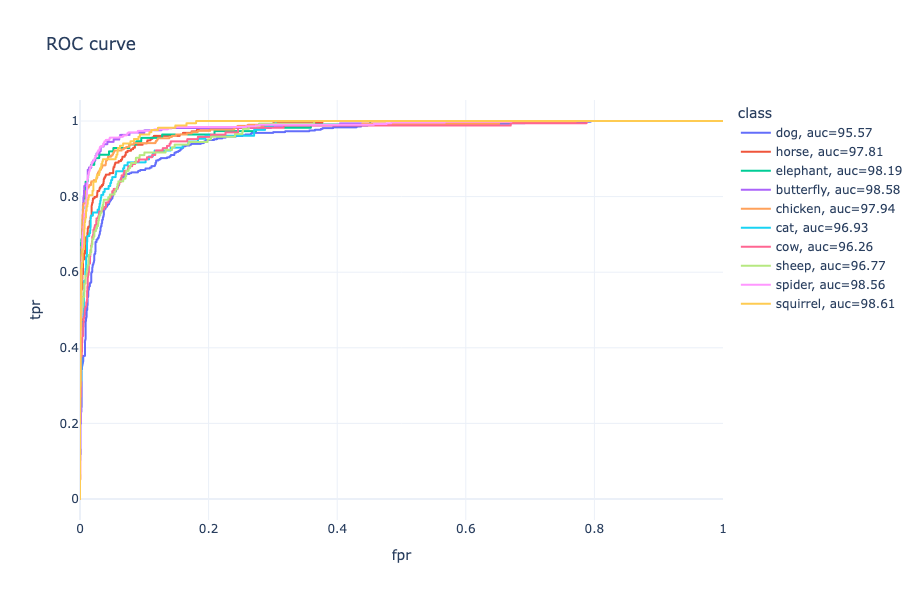

In [10]:
df = pd.DataFrame(df_dict)
px.line(df, x='fpr', y='tpr', color='class', 
        width=800, height=600, title="ROC curve")

Let's try to tune the threshold for the dog class (which has index 0)

In [11]:
with torch.no_grad():
    val_pred_probs = []
    val_pred_classes = []
    val_true_classes = []
    for batch_x, batch_y in tqdm.tqdm(val_loader):
        out_t = model(batch_x)
        probs_t = torch.softmax(out_t, -1)
        preds_t = torch.argmax(probs_t, -1)
        val_true_classes.extend(batch_y.detach().numpy())
        val_pred_classes.extend(preds_t.detach().numpy())
        val_pred_probs.extend(probs_t.detach().numpy())
val_pred_probs = np.array(val_pred_probs)
val_pred_classes = np.array(val_pred_classes)
val_true_classes = np.array(val_true_classes)
print(classification_report(val_true_classes, val_pred_classes, target_names=images_classes_en))

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [00:23<00:00,  1.24s/it]

              precision    recall  f1-score   support

         dog       0.81      0.71      0.76       477
       horse       0.84      0.75      0.79       246
    elephant       0.75      0.78      0.76       101
   butterfly       0.82      0.86      0.84       174
     chicken       0.88      0.84      0.86       326
         cat       0.68      0.71      0.69       136
         cow       0.63      0.87      0.73       199
       sheep       0.71      0.73      0.72       130
      spider       0.91      0.87      0.89       449
    squirrel       0.74      0.81      0.77       183

    accuracy                           0.80      2421
   macro avg       0.78      0.79      0.78      2421
weighted avg       0.81      0.80      0.80      2421



In [12]:
true_dog = (true_classes == 0).astype(np.int32)
probs_dog = pred_probs[:, 0]

In [13]:
precision, recall, threshold = precision_recall_curve(true_dog, probs_dog)

In [14]:
f1 = 2*precision[:-1]*recall[:-1] / (precision[:-1] + recall[:-1] + 1e-10)
idx = np.argmax(f1)
best_threshold = threshold[idx]
best_f1 = f1[idx]
best_threshold, best_f1

(np.float32(0.19295296), np.float64(0.8047808764441382))

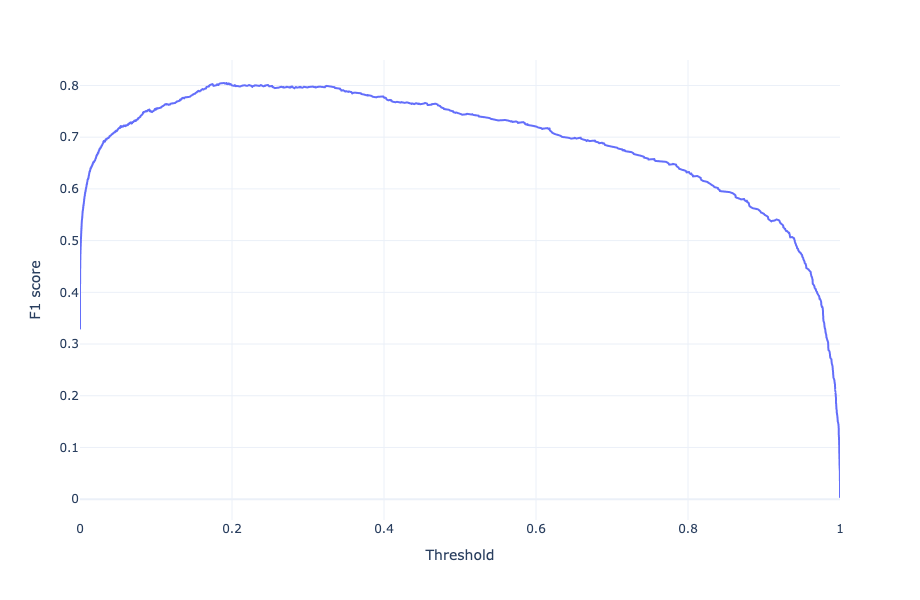

In [15]:
px.line(x=threshold, y=f1, width=800, height=600, 
        labels={"x": "Threshold", "y": "F1 score"})

Compute thresholds for all classes

In [16]:
df_dict = {"threshold": [], "f1": [], "class": []}
class_thresholds = {}
for i, class_name in enumerate(images_classes_en):
    true_i = (val_true_classes == i).astype(np.int32)
    precision, recall, threshold = precision_recall_curve(
        true_i, val_pred_probs[:, i])
    f1 = 2*precision[:-1]*recall[:-1] / (precision[:-1] + recall[:-1] + 1e-10)
    idx = np.argmax(f1)
    best_threshold = threshold[idx]
    best_f1 = f1[idx]
    print(f"{class_name:15s} best F1={best_f1*100:.2f}%, "
          f"threshold={best_threshold:.5f}")
    label = f"{class_name}, f1={best_f1*100:.2f}%"
    df_dict['threshold'].extend(threshold)
    df_dict['f1'].extend(f1)
    df_dict['class'].extend([label for _ in range(len(f1))])
    class_thresholds[i] = best_threshold

dog             best F1=79.47%, threshold=0.24607
horse           best F1=81.95%, threshold=0.29294
elephant        best F1=82.35%, threshold=0.61292
butterfly       best F1=86.98%, threshold=0.63247
chicken         best F1=87.64%, threshold=0.49604
cat             best F1=71.54%, threshold=0.54028
cow             best F1=78.41%, threshold=0.67883
sheep           best F1=75.18%, threshold=0.30712
spider          best F1=90.27%, threshold=0.29116
squirrel        best F1=77.84%, threshold=0.36705


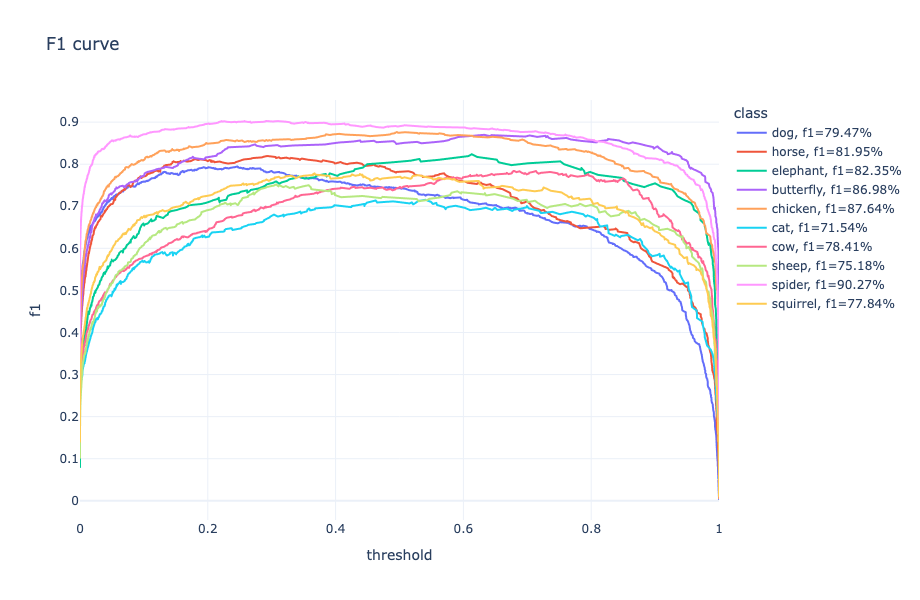

In [17]:
df = pd.DataFrame(df_dict)
px.line(df, x='threshold', y='f1', color='class', 
        width=800, height=600, title="F1 curve")

In [30]:
import matplotlib.pylab as plt

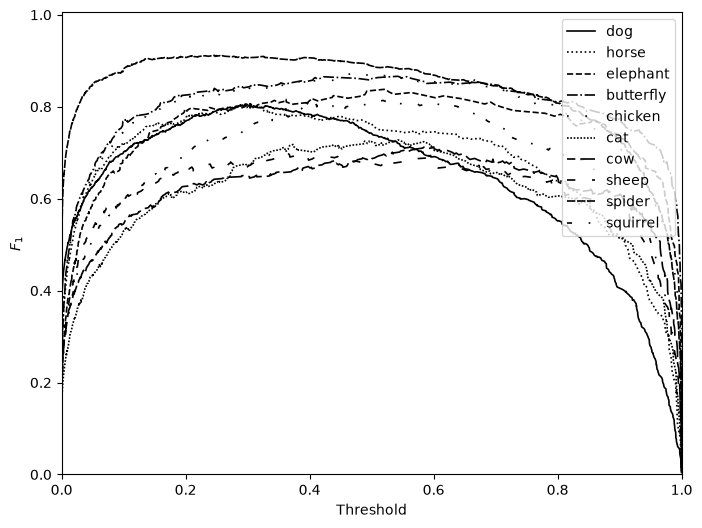

In [31]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
styles = ["solid", "dotted", "dashed", "dashdot", 
          (0, (1, 10)), (0, (1, 1)), (5, (10, 3)), (0, (5, 10)), (0, (5, 1)), (0, (3, 10, 1, 10))]
for style, class_name in zip(styles, images_classes_en):
    sub_df = df[df['class'].str.startswith(class_name)]
    threshold = sub_df.threshold
    f1 = sub_df.f1
    ax.plot(threshold, f1, linestyle=style, color='black', lw=1.2)
ax.legend(images_classes_en, loc='upper right')
ax.set_xlabel("Threshold")
ax.set_ylabel("$F_1$")
ax.set_xlim(0.0, 1)
ax.set_ylim(0.0, 1.005)
fig.savefig("conv-aug-f1-threshold-all.svg")

# Temperature scaling of the model

In [18]:
log_temperature = torch.nn.Parameter(torch.zeros(len(images_classes)))
optimizer = torch.optim.Adam([log_temperature], lr=0.01)
loss = nn.CrossEntropyLoss()

In [20]:
for epoch in range(10):
    losses = []
    for batch_x, batch_y in tqdm.tqdm(val_loader):
        optimizer.zero_grad()
        logits_t = model(batch_x)
        temperature = log_temperature.exp()
        loss_t = loss(logits_t / temperature, batch_y)
        loss_t.backward()
        optimizer.step()
        losses.append(loss_t.detach().item())
    mean_loss = np.mean(losses)
    print(f"{epoch}: loss={mean_loss:.5f}, temperature={log_temperature.exp()}")
temperature

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [01:01<00:00,  3.25s/it]


0: loss=0.66184, temperature=tensor([1.1550, 1.1164, 1.0545, 1.0346, 1.1025, 1.0401, 0.9355, 1.0562, 1.0930,
        1.0581], grad_fn=<ExpBackward0>)


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [01:04<00:00,  3.42s/it]


1: loss=0.64506, temperature=tensor([1.2740, 1.2042, 1.0846, 1.0699, 1.1869, 1.1177, 0.9282, 1.0796, 1.1608,
        1.1234], grad_fn=<ExpBackward0>)


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [01:02<00:00,  3.28s/it]


...

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [01:00<00:00,  3.18s/it]


8: loss=0.62305, temperature=tensor([1.5514, 1.4476, 1.2675, 1.2824, 1.4774, 1.3340, 1.0796, 1.2385, 1.4357,
        1.3505], grad_fn=<ExpBackward0>)


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [01:01<00:00,  3.23s/it]

9: loss=0.62398, temperature=tensor([1.5748, 1.4733, 1.2602, 1.2895, 1.4590, 1.3097, 1.0789, 1.2434, 1.4434,
        1.3426], grad_fn=<ExpBackward0>)


tensor([1.5732, 1.4743, 1.2593, 1.2878, 1.4605, 1.3067, 1.0775, 1.2421, 1.4425,
        1.3417], grad_fn=<ExpBackward0>)

In [32]:
with torch.no_grad():
    pred_probs = []
    pred_classes = []
    true_classes = []
    for batch_x, batch_y in tqdm.tqdm(test_loader):
        out_t = model(batch_x)
        probs_t = torch.softmax(out_t / temperature, -1)
        preds_t = torch.argmax(probs_t, -1)
        true_classes.extend(batch_y.detach().numpy())
        pred_classes.extend(preds_t.detach().numpy())
        pred_probs.extend(probs_t.detach().numpy())
pred_probs = np.array(pred_probs)
pred_classes = np.array(pred_classes)
true_classes = np.array(true_classes)
print(classification_report(true_classes, pred_classes, target_names=images_classes_en))

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [00:24<00:00,  1.29s/it]

              precision    recall  f1-score   support

         dog       0.82      0.76      0.79       478
       horse       0.82      0.70      0.76       254
    elephant       0.81      0.84      0.82       112
   butterfly       0.85      0.85      0.85       163
     chicken       0.85      0.85      0.85       307
         cat       0.67      0.76      0.71       128
         cow       0.58      0.80      0.67       167
       sheep       0.70      0.65      0.67       144
      spider       0.93      0.88      0.91       500
    squirrel       0.73      0.85      0.78       168

    accuracy                           0.80      2421
   macro avg       0.78      0.79      0.78      2421
weighted avg       0.81      0.80      0.80      2421



In [33]:
df_dict = {"threshold": [], "f1": [], "class": []}
class_thresholds = {}
for i, class_name in enumerate(images_classes_en):
    true_i = (true_classes == i).astype(np.int32)
    precision, recall, threshold = precision_recall_curve(
        true_i, pred_probs[:, i])
    f1 = 2*precision[:-1]*recall[:-1] / (precision[:-1] + recall[:-1] + 1e-10)
    idx = np.argmax(f1)
    best_threshold = threshold[idx]
    best_f1 = f1[idx]
    best_threshold, best_f1
    print(f"{class_name:15s} best F1={best_f1*100:.2f}%, "
          f"threshold={best_threshold:.5f}")
    auc_score = auc(fpr, tpr) * 100
    label = f"{class_name}, f1={best_f1*100:.2f}%"
    df_dict['threshold'].extend(threshold)
    df_dict['f1'].extend(f1)
    df_dict['class'].extend([label for _ in range(len(f1))])
    class_thresholds[i] = best_threshold

dog             best F1=80.62%, threshold=0.29715
horse           best F1=80.31%, threshold=0.29587
elephant        best F1=83.81%, threshold=0.52221
butterfly       best F1=86.62%, threshold=0.54249
chicken         best F1=87.22%, threshold=0.47747
cat             best F1=72.80%, threshold=0.54231
cow             best F1=71.26%, threshold=0.60034
sheep           best F1=70.00%, threshold=0.36428
spider          best F1=91.16%, threshold=0.24694
squirrel        best F1=81.37%, threshold=0.51862


Thresholds for uncalibrated model:
```   
dog             best F1=79.47%, threshold=0.24607
horse           best F1=81.95%, threshold=0.29294
elephant        best F1=82.35%, threshold=0.61292
butterfly       best F1=86.98%, threshold=0.63247
chicken         best F1=87.64%, threshold=0.49604
cat             best F1=71.54%, threshold=0.54028
cow             best F1=78.41%, threshold=0.67883
sheep           best F1=75.18%, threshold=0.30712
spider          best F1=90.27%, threshold=0.29116
squirrel        best F1=77.84%, threshold=0.36705
```

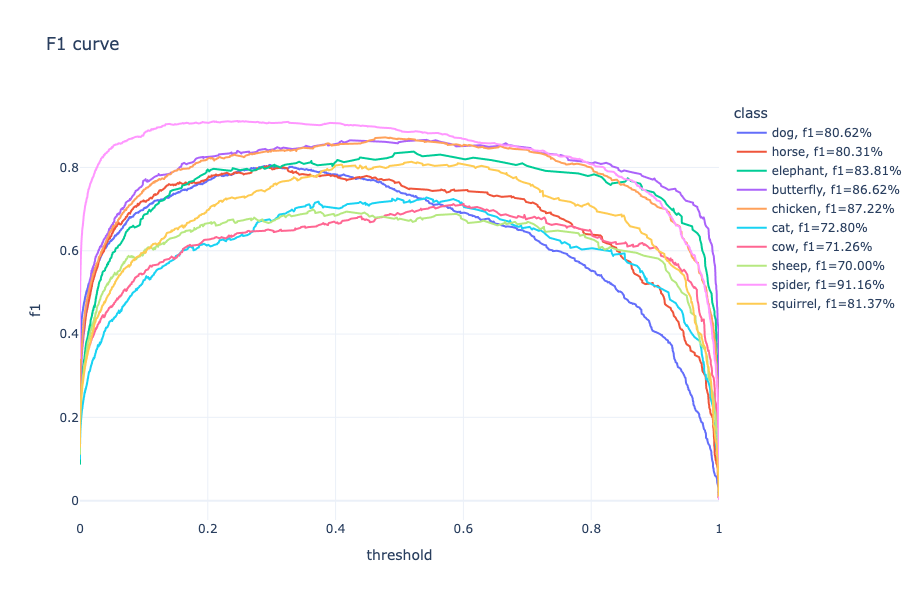

In [25]:
df = pd.DataFrame(df_dict)
px.line(df, x='threshold', y='f1', color='class', 
        width=800, height=600, title="F1 curve")

# Perform classification using thresholds
With thresholds, our model can now produce "UNKNOWN" result (if all predictions are below threshold)

In [34]:
with torch.no_grad():
    pred_probs = []
    pred_classes = []
    true_classes = []
    uncertains = []
    for batch_x, batch_y in test_loader:
        out_t = model(batch_x)
        probs_t = torch.softmax(out_t, -1)
        probs = probs_t.detach().numpy()
        batch_classes = batch_y.detach().numpy()
        for row_idx, true_class in enumerate(batch_classes):
            classes = []
            argmax_class = np.argmax(probs[row_idx])
            for class_idx in range(len(images_classes)):
                p = probs[row_idx, class_idx]
                if p > class_thresholds[class_idx]:
                    classes.append((p, class_idx))
            if len(classes) == 0:
                if len(uncertains) < 10:
                    print(f"Uncertain about {images_classes_en[true_class]}, "
                          f"argmax class {images_classes_en[argmax_class]}")
                uncertains.append(data.denorm_image(batch_x[row_idx].detach().numpy()))
            elif len(classes) == 1:
                c, p = classes[0]
                pred_classes.append(p)
                pred_probs.append(c)
                true_classes.append(true_class)
            elif len(classes) > 1:
                classes.sort(reverse=True)
                c, p = classes[0]
                pred_classes.append(p)
                pred_probs.append(c)
                true_classes.append(true_class)
len(uncertains), len(test_dataset)

Uncertain about horse, argmax class elephant
Uncertain about dog, argmax class dog
Uncertain about cat, argmax class cat
Uncertain about squirrel, argmax class cow
Uncertain about cat, argmax class cat
Uncertain about squirrel, argmax class squirrel
Uncertain about cow, argmax class chicken
Uncertain about dog, argmax class cow
Uncertain about cat, argmax class squirrel
Uncertain about elephant, argmax class elephant


(107, 2421)

In [27]:
print(classification_report(true_classes, pred_classes, target_names=images_classes_en))

              precision    recall  f1-score   support

         dog       0.84      0.77      0.81       455
       horse       0.84      0.79      0.81       243
    elephant       0.86      0.85      0.86       105
   butterfly       0.88      0.85      0.86       160
     chicken       0.88      0.86      0.87       295
         cat       0.72      0.77      0.74       118
         cow       0.64      0.81      0.71       157
       sheep       0.69      0.76      0.72       128
      spider       0.92      0.90      0.91       495
    squirrel       0.79      0.85      0.82       158

    accuracy                           0.83      2314
   macro avg       0.81      0.82      0.81      2314
weighted avg       0.84      0.83      0.83      2314



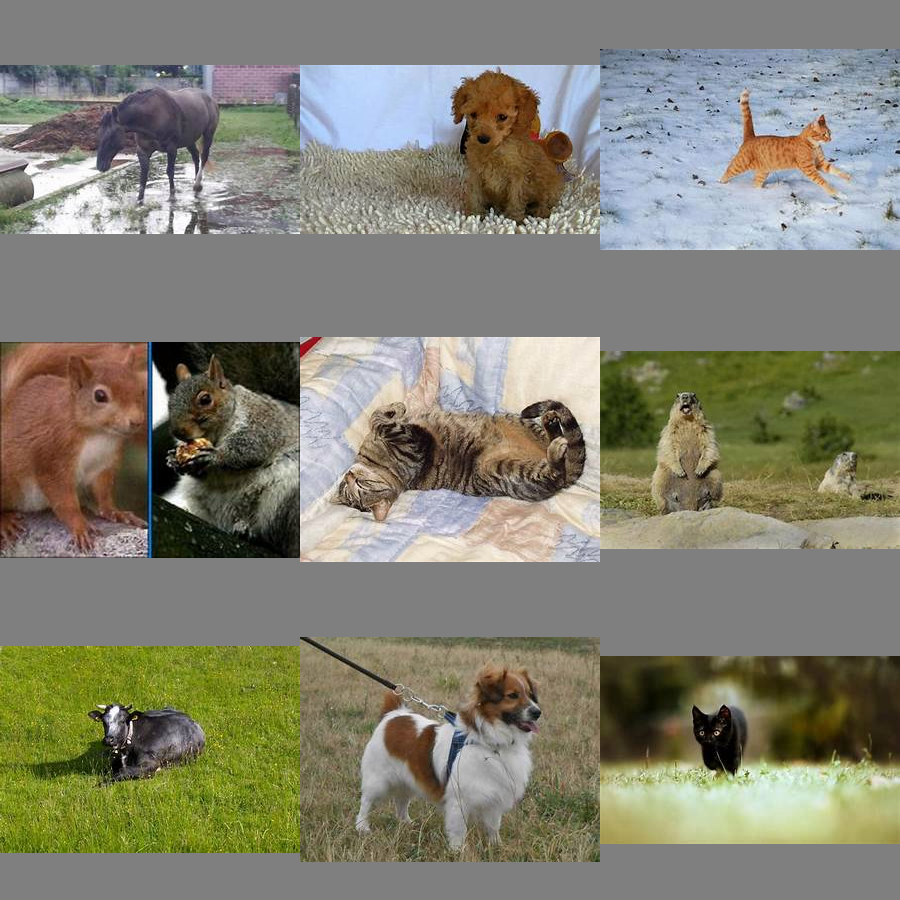

In [35]:
grid = Image.new("RGB", (3*300, 3*300), "white")
for row in range(3): 
    for col in range(3):
        grid.paste(Image.fromarray(uncertains[row*3+col]), (col*300, row*300))
grid

In [36]:
grid.save("uncertain-aug.png")